 ## STEP 1 — Import Libraries & Load Data|

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('ecommerce_sales.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')  # (rows, columns)

Dataset loaded successfully!
Shape: (510, 14)


##  STEP 2 — data reading

In [2]:
# First 5 rows
df.head()

,order_id,customer_name,age,country,city,category,product_price,quantity,discount_percent,payment_method,order_status,order_date,rating,total_amount
0,ORD0001,Customer_1,56.0,India,Sydney,Books,2655.52,5,20.0,Cash,Delivered,2023-01-01,5.0,10622.08
1,ORD0002,Customer_2,46.0,UK,London,Toys,6601.69,8,10.0,Net Banking,Cancelled,2023-01-01,NaN,47532.17
2,ORD0003,Customer_3,32.0,France,Toronto,Sports,3319.38,8,10.0,UPI,Delivered,2023-01-02,4.0,23899.54
3,ORD0004,Customer_4,60.0,UK,London,Books,7757.38,1,0.0,UPI,Delivered,2023-01-02,3.0,7757.38
4,ORD0005,Customer_5,25.0,India,Tokyo,Sports,1395.65,5,20.0,Net Banking,Delivered,2023-01-03,NaN,5582.60


In [3]:
# Last 5 rows
df.tail()

,order_id,customer_name,age,country,city,category,product_price,quantity,discount_percent,payment_method,order_status,order_date,rating,total_amount
505,ORD0304,Customer_304,38.0,USA,New York,Electronics,9235.30,2,10.0,Cash,Delivered,2023-06-01,4.0,16623.54
506,ORD0446,Customer_446,18.0,France,New York,Home,8007.27,4,5.0,UPI,Delivered,2023-08-11,3.0,30427.63
507,ORD0108,Customer_108,50.0,Germany,Toronto,Books,2451.69,5,25.0,UPI,Delivered,2023-02-23,2.0,9193.84
508,ORD0139,Customer_139,NaN,UAE,New York,Food,9350.92,6,10.0,UPI,Delivered,2023-03-11,4.0,50494.97
509,ORD0116,Customer_116,25.0,Australia,Dubai,Electronics,3859.88,7,0.0,Net Banking,Delivered,2023-02-27,4.0,27019.16


In [4]:
# Shape: how many rows and columns
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 510
Columns: 14


In [5]:
# Column names
df.columns.tolist()

['order_id',
 'customer_name',
 'age',
 'country',
 'city',
 'category',
 'product_price',
 'quantity',
 'discount_percent',
 'payment_method',
 'order_status',
 'order_date',
 'rating',
 'total_amount']

In [6]:
# Data types of each column
df.dtypes

order_id             object
customer_name        object
age                 float64
country              object
city                 object
category             object
product_price       float64
quantity              int64
discount_percent    float64
payment_method       object
order_status         object
order_date           object
rating              float64
total_amount        float64
dtype: object

In [7]:
# Full overview — nulls, types, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          510 non-null    object 
 1   customer_name     510 non-null    object 
 2   age               499 non-null    float64
 3   country           510 non-null    object 
 4   city              510 non-null    object 
 5   category          510 non-null    object 
 6   product_price     510 non-null    float64
 7   quantity          510 non-null    int64  
 8   discount_percent  500 non-null    float64
 9   payment_method    510 non-null    object 
 10  order_status      510 non-null    object 
 11  order_date        510 non-null    object 
 12  rating            481 non-null    float64
 13  total_amount      510 non-null    float64
dtypes: float64(5), int64(1), object(8)
memory usage: 55.9+ KB


In [8]:
# Statistical summary — mean, min, max, std
df.describe()

,age,product_price,quantity,discount_percent,rating,total_amount
count,499.000000,510.000000,510.000000,500.00000,481.000000,510.000000
mean,41.190381,5078.909784,5.107843,12.34000,3.806653,22737.622980
std,13.482617,2867.172053,2.553579,8.35248,1.107756,18297.005811
min,18.000000,148.910000,1.000000,0.00000,1.000000,133.460000
25%,30.000000,2484.117500,3.000000,5.00000,3.000000,7508.180000
50%,42.000000,5204.815000,5.000000,10.00000,4.000000,18518.600000
75%,52.000000,7482.102500,7.000000,20.00000,5.000000,33128.562500
max,64.000000,9994.200000,9.000000,25.00000,5.000000,88545.780000


## STEP 3 — Handling Missing Values 

In [9]:
# Count missing values per column
df.isnull().sum()

order_id             0
customer_name        0
age                 11
country              0
city                 0
category             0
product_price        0
quantity             0
discount_percent    10
payment_method       0
order_status         0
order_date           0
rating              29
total_amount         0
dtype: int64

In [10]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].round(2))

age                 2.16
discount_percent    1.96
rating              5.69
dtype: float64


In [11]:
# Fill missing age with median (better than mean — not affected by outliers)
df['age'].fillna(df['age'].median(), inplace=True)

# Fill missing rating with median
df['rating'].fillna(df['rating'].median(), inplace=True)

# Fill missing discount_percent with 0 (assume no discount)
df['discount_percent'].fillna(0, inplace=True)

print('Missing values after filling:')
print(df.isnull().sum())

Missing values after filling:
order_id            0
customer_name       0
age                 0
country             0
city                0
category            0
product_price       0
quantity            0
discount_percent    0
payment_method      0
order_status        0
order_date          0
rating              0
total_amount        0
dtype: int64


C:\Users\adity\AppData\Local\Temp\ipykernel_24420\2469955264.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_24420\2469955264.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

## STEP 4 — Removing Duplicates

In [12]:
# Check for duplicates
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 10


In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (500, 14)


##  STEP 5 — Data Type Conversion & Fixing Columns

In [14]:
# Convert order_date from string to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Convert rating to integer
df['rating'] = df['rating'].astype(int)

# Convert age to integer
df['age'] = df['age'].astype(int)

print('Updated dtypes:')
print(df[['order_date', 'rating', 'age']].dtypes)

Updated dtypes:
order_date    datetime64[ns]
rating                 int64
age                    int64
dtype: object


##  STEP 6 — Filtering & Selecting Data 

In [15]:
# Select one column
df['category'].head()

0     Books
1      Toys
2    Sports
3     Books
4    Sports
Name: category, dtype: object

In [16]:
# Select multiple columns
df[['order_id', 'category', 'total_amount', 'order_status']].head()

,order_id,category,total_amount,order_status
0,ORD0001,Books,10622.08,Delivered
1,ORD0002,Toys,47532.17,Cancelled
2,ORD0003,Sports,23899.54,Delivered
3,ORD0004,Books,7757.38,Delivered
4,ORD0005,Sports,5582.60,Delivered


In [17]:
# Filter: only delivered orders
delivered = df[df['order_status'] == 'Delivered']
print('Delivered orders:', len(delivered))

Delivered orders: 321


In [18]:
# Filter: orders from India with amount > 5000
india_high_value = df[(df['country'] == 'India') & (df['total_amount'] > 5000)]
print('High value India orders:', len(india_high_value))

High value India orders: 52


In [19]:
# Filter: Electronics or Books category
df[df['category'].isin(['Electronics', 'Books'])].shape

(128, 14)

##  STEP 7 — Creating New Columns 

In [20]:
# Revenue after discount (recalculate cleanly)
df['final_revenue'] = (df['product_price'] * df['quantity'] * 
                       (1 - df['discount_percent'] / 100)).round(2)

# Discount amount saved
df['discount_amount'] = (df['product_price'] * df['quantity'] * 
                         df['discount_percent'] / 100).round(2)

# Extract month and year from order_date
df['order_month'] = df['order_date'].dt.month_name()
df['order_year'] = df['order_date'].dt.year
df['order_quarter'] = df['order_date'].dt.quarter

# Age group segmentation
df['age_group'] = pd.cut(df['age'], 
                          bins=[17, 25, 35, 45, 65], 
                          labels=['18-25', '26-35', '36-45', '46-65'])

# High value order flag
df['is_high_value'] = df['final_revenue'] > df['final_revenue'].median()

df.head(3)

,order_id,customer_name,age,country,city,category,product_price,quantity,discount_percent,payment_method,...,order_date,rating,total_amount,final_revenue,discount_amount,order_month,order_year,order_quarter,age_group,is_high_value
0,ORD0001,Customer_1,56,India,Sydney,Books,2655.52,5,20.0,Cash,...,2023-01-01,5,10622.08,10622.08,2655.52,January,2023,1,46-65,False
1,ORD0002,Customer_2,46,UK,London,Toys,6601.69,8,10.0,Net Banking,...,2023-01-01,4,47532.17,47532.17,5281.35,January,2023,1,46-65,True
2,ORD0003,Customer_3,32,France,Toronto,Sports,3319.38,8,10.0,UPI,...,2023-01-02,4,23899.54,23899.54,2655.50,January,2023,1,26-35,True


## STEP 8 — GroupBy & Aggregations

In [21]:
# Total revenue by category
df.groupby('category')['final_revenue'].sum().sort_values(ascending=False).round(2)

category
Home           1523361.43
Beauty         1497470.44
Toys           1483412.75
Clothing       1477796.44
Sports         1444898.71
Books          1328406.25
Electronics    1326019.94
Food           1280592.18
Name: final_revenue, dtype: float64

In [22]:
# Average order value by country
df.groupby('country')['final_revenue'].mean().sort_values(ascending=False).round(2)

country
Canada       28786.01
Japan        24237.06
France       24190.21
UAE          23797.47
USA          22507.81
Australia    21937.49
UK           21775.59
India        20828.61
Germany      20266.63
Brazil       19722.43
Name: final_revenue, dtype: float64

In [23]:
# Multiple aggregations at once
df.groupby('category').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('final_revenue', 'sum'),
    avg_rating=('rating', 'mean'),
    avg_discount=('discount_percent', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

,total_orders,total_revenue,avg_rating,avg_discount
category,,,,
Home,58,1523361.43,3.84,11.64
Beauty,66,1497470.44,3.88,13.41
Toys,62,1483412.75,3.84,11.85
Clothing,64,1477796.44,3.77,12.58
Sports,62,1444898.71,3.66,10.40
Books,71,1328406.25,3.80,12.61
Electronics,57,1326019.94,3.88,10.88
Food,60,1280592.18,3.88,13.00


In [24]:
# Cancellation rate by category
cancel_rate = df.groupby('category')['order_status'].apply(
    lambda x: (x == 'Cancelled').sum() / len(x) * 100
).round(2)
print('Cancellation rate by category (%):')
print(cancel_rate.sort_values(ascending=False))

Cancellation rate by category (%):
category
Books          21.13
Toys           20.97
Food           18.33
Sports         17.74
Clothing       15.62
Electronics    14.04
Home           12.07
Beauty         10.61
Name: order_status, dtype: float64


In [25]:
# Orders per payment method
df['payment_method'].value_counts()

payment_method
Credit Card    108
Net Banking    105
Cash           101
UPI            100
Debit Card      86
Name: count, dtype: int64

In [26]:
# Revenue by age group
df.groupby('age_group', observed=True)['final_revenue'].agg(['sum', 'mean', 'count']).round(2)

,sum,mean,count
age_group,,,
18-25,1971365.15,22150.17,89
26-35,2210306.36,26954.96,82
36-45,2725040.75,21800.33,125
46-65,4455245.88,21839.44,204


##  STEP 9 — Sorting & Ranking 

In [27]:
# Top 10 highest value orders
df.sort_values('final_revenue', ascending=False)[['order_id', 'category', 'country', 'final_revenue']].head(10)

,order_id,category,country,final_revenue
335,ORD0336,Electronics,UAE,88545.78
129,ORD0130,Books,UK,86037.12
240,ORD0241,Electronics,UK,81913.19
332,ORD0333,Food,Canada,79593.44
93,ORD0094,Electronics,Canada,72879.03
390,ORD0391,Home,Germany,72639.36
398,ORD0399,Beauty,France,72219.52
36,ORD0037,Food,Japan,71024.74
371,ORD0372,Clothing,UK,70280.28
473,ORD0474,Beauty,UAE,68174.28


In [28]:
# Rank orders by revenue within each category
df['revenue_rank'] = df.groupby('category')['final_revenue'].rank(ascending=False, method='dense').astype(int)
df[df['revenue_rank'] == 1][['category', 'order_id', 'final_revenue']].sort_values('final_revenue', ascending=False)

,category,order_id,final_revenue
335,Electronics,ORD0336,88545.78
129,Books,ORD0130,86037.12
332,Food,ORD0333,79593.44
390,Home,ORD0391,72639.36
398,Beauty,ORD0399,72219.52
371,Clothing,ORD0372,70280.28
461,Sports,ORD0462,67942.44
57,Toys,ORD0058,61123.42


##  STEP 10 — String Operations & Cleaning 

In [29]:
# Convert category to uppercase
df['category_upper'] = df['category'].str.upper()

# Check if customer name contains a specific pattern
df[df['customer_name'].str.contains('1$', regex=True)].head(3)


,order_id,customer_name,age,country,city,category,product_price,quantity,discount_percent,payment_method,...,total_amount,final_revenue,discount_amount,order_month,order_year,order_quarter,age_group,is_high_value,revenue_rank,category_upper
0,ORD0001,Customer_1,56,India,Sydney,Books,2655.52,5,20.0,Cash,...,10622.08,10622.08,2655.52,January,2023,1,46-65,False,37,BOOKS
10,ORD0011,Customer_11,28,USA,Berlin,Toys,5245.76,2,25.0,Credit Card,...,7868.64,7868.64,2622.88,January,2023,1,26-35,False,45,TOYS
20,ORD0021,Customer_21,47,UK,Dubai,Food,7390.38,6,20.0,Cash,...,35473.82,35473.82,8868.46,January,2023,1,46-65,True,16,FOOD


In [30]:
# Extract order number from order_id
df['order_number'] = df['order_id'].str.replace('ORD', '').astype(int)
df[['order_id', 'order_number']].head()

,order_id,order_number
0,ORD0001,1
1,ORD0002,2
2,ORD0003,3
3,ORD0004,4
4,ORD0005,5


##  STEP 11 — Quick Visualizations

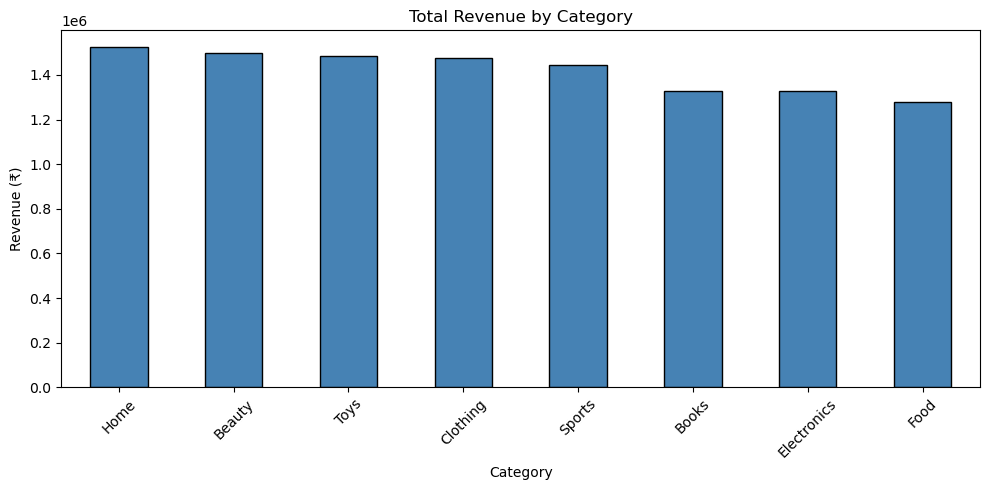

In [31]:
# Revenue by category — bar chart
rev_by_cat = df.groupby('category')['final_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rev_by_cat.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

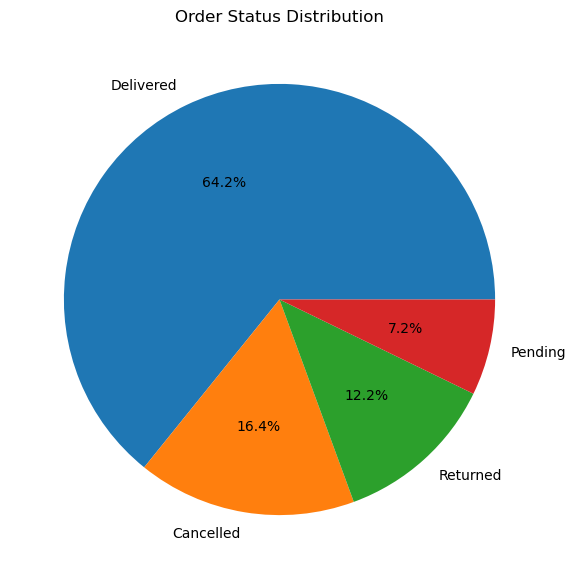

In [32]:
# Order status distribution — pie chart
df['order_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Order Status Distribution')
plt.ylabel('')
plt.show()

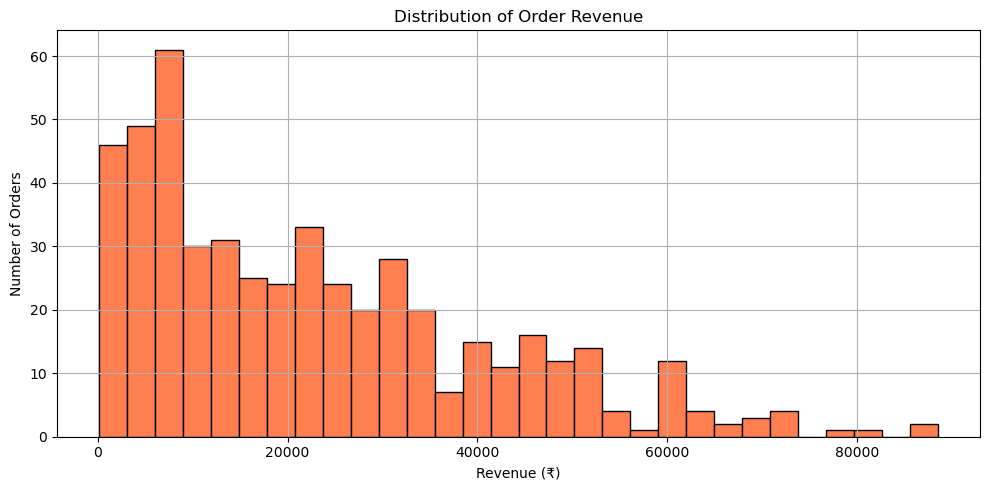

In [33]:
# Revenue distribution — histogram
plt.figure(figsize=(10, 5))
df['final_revenue'].hist(bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Order Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## STEP 12 — Export Cleaned Data

In [34]:
# Save cleaned dataset to CSV
df.to_csv('ecommerce_sales_cleaned.csv', index=False)
print('Cleaned dataset saved!')
print(f'Final shape: {df.shape}')

Cleaned dataset saved!
Final shape: (500, 24)
